In [36]:
import torch

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

print(torch.__version__)

cuda
2.11.0+cu128


In [38]:
# 피자 크기에 관련한 예측하는 모델

def pizza_price_model(size):
    weight = 2
    bias = 3
    price = weight * size + bias
    return price

size = 5
predicted_price = pizza_price_model(size)
print(predicted_price)

13


In [39]:
# 순전파 함수 만들기

import torch

def forward_pass(x, w, b):
    z = torch.mm(x, w) + b
    output = torch.relu(z)
    return output

x = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0]])
w = torch.tensor([[0.5, -0.5],
                  [1.0, 1.0]])
b = torch.tensor([[1.0, 1.0]])

output = forward_pass(x, w, b)
print(output)

tensor([[3.5000, 2.5000],
        [6.5000, 3.5000]])


In [40]:
# 손실 계산

import torch
import torch.nn as nn

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = 2 * x + 1

model_output = torch.tensor([[2.5], [3.5], [4.5], [5.5]])

criterion = nn.MSELoss()

loss = criterion(model_output, y_true) # 순서는 반드시 기억 / 예측값이 앞, 정답이 뒤
print(loss)

tensor(5.2500)


In [41]:
# 역전파 / 오답노트를 만들어가며 다시 학습해가는 것

actual_price = 11
predicted_price = 13

error = predicted_price - actual_price

print(error)

weight = 2
bias = 3
learning_rate = 0.01

weight = weight - learning_rate * error * size
bias = bias - learning_rate * error

price = weight * size + bias
print(price) # learning_rate 를조정하여 오차값을 줄여가거나 없에는 행위 = 역전파

2
12.48


In [42]:
# 파이토치에서는 역전파가 함수사용으로 자동으로 계산됨

import torch

# Input
x = torch.tensor(2.0, requires_grad = True)

# Forward(순전파)
y = x ** 2 + 3 * x + 4

# Backward
y. backward()

print(x.grad) # 기울기가 구해지고나면 기울기를 조정해가며 값을 찾을 수 있음

tensor(7.)


In [43]:
# 역전파를 하기위해선 loss를 알아야함 앞선 표현에선 error

import torch

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad = True)
y = (x ** 2).sum() # 벡터값

y.backward()
print(x.grad) # 벡터에 맞춰진 로스가 구해짐

tensor([[2., 4.],
        [6., 8.]])


In [44]:
# 선형 회귀

import torch
import torch.nn as nn
import torch.optim as optim


class LinearRegressionModel(nn.Module): # 모델 사용시 클래스를 생성
    def __init__(self, input_dim, output_dim): # 함수 init
        super(LinearRegressionModel, self).__init__()
        self.Linear = nn.Linear(input_dim, output_dim)

    def forward(self, x): # forward를 실행
        return self.Linear(x)


x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y_true = 2 * x + 1 # 실제정답인 y_true를 생성

model = LinearRegressionModel(1, 1) # 모델선언
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad() # 에러를 초기화 해줌
    pred = model(x) # 순전파
    loss = criterion(pred, y_true) # 로스계산
    loss.backward() # 역전파 (오류만큼 weight, bias 새로 계산)
    optimizer.step() # 역전파의 가중치가 optimizer에 적용
    if (epoch + 1) % 20 == 0:
        print(epoch + 1, loss.item())

20 0.06464047729969025
40 0.027239803224802017
60 0.02414095029234886
80 0.021412484347820282
100 0.018992338329553604


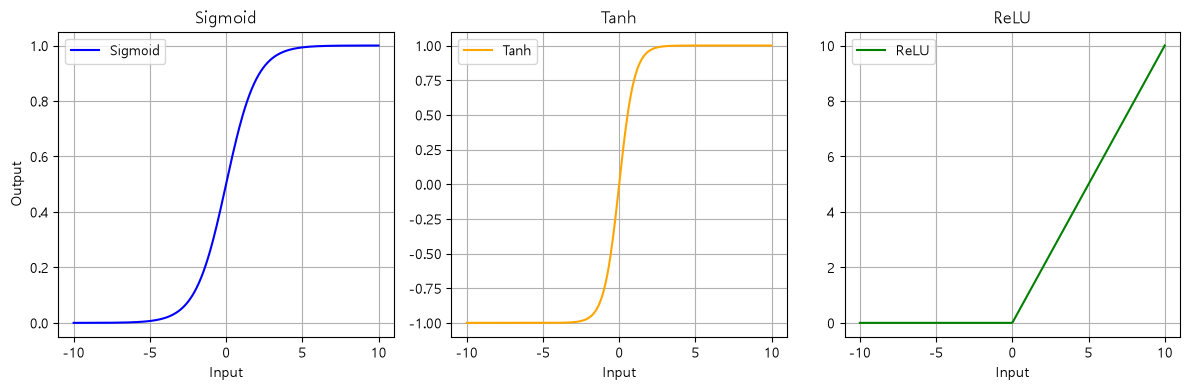

In [45]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np. maximum(0, x) # x가 음수가 들어와도 0을 뜻함 x가 음수면 0 양수면 양수를 선택

y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

plt.figure(figsize=(12, 4))

# 1) Sigmoid 이진분류에서만 사용 (0아니면 1) / 분류에서 사용
plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid, label='Sigmoid', color='blue')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid')
plt.grid(True)
plt.legend()

# 2) Tanh -1~1 사이의 값
plt.subplot(1, 3, 2)
plt.plot(x, y_tanh, label='Tanh', color='orange')
plt.xlabel('Input')
plt.title('Tanh')
plt.grid(True)
plt.legend()

# 3) ReLU 0 이고 나머지는 양수는 무한대로 증식
plt.subplot(1, 3, 3)
plt.plot(x, y_relu, label='ReLU', color='green')
plt.xlabel('Input')
plt.title('ReLU')
plt.grid(True)
plt.legend()

# 서브플롯 간 여백 조정
plt.tight_layout()

plt.show()

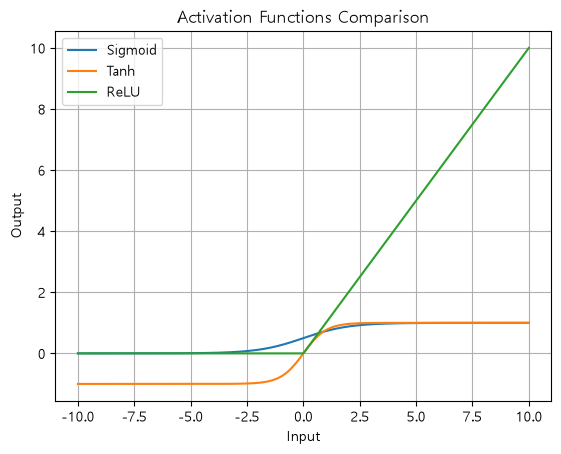

In [46]:
# plt.figure(figsize=(8, 6))
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# MNIST 데이터셋 활용

from torchvision import datasets, transforms

transform = transforms.Compose([transforms.RandomRotation(10),
                                transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root = "./data",
                              train = True,
                              download = True,
                              transform = transform)

In [48]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True) # 트레인 셋만 셔플 출력
data_iter = iter(train_loader)

images, labels = next(data_iter)
print(images.shape)

torch.Size([64, 1, 28, 28])


In [ ]:
# 전체 루프 MNIST 를 SimpleMLP

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(), nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.fc1(x)


transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))]) #MLP의 평균과 오차평균

train_dataset = datasets.MNIST(root="./data",
                               train=True,
                               download=True,
                               transform=transform)
test_dataset = datasets.MNIST(root="./data",
                              train=False,
                              download=True,
                              transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(epoch + 1, avg_loss)

def evaluate(model, data_loader):
    model.eval() # 필수 1 evaluate 함수 핵심
    correct = 0
    total = 0
    with torch.no_grad(): # 필수 2 evaluate 함수 핵심
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

test_accuracy = evaluate(model, test_loader)
print(test_accuracy)

1 0.2611188720296155
2 0.11491609515864522
3 0.08032629770864207
4 0.06164224140161374
5 0.04814157628594264


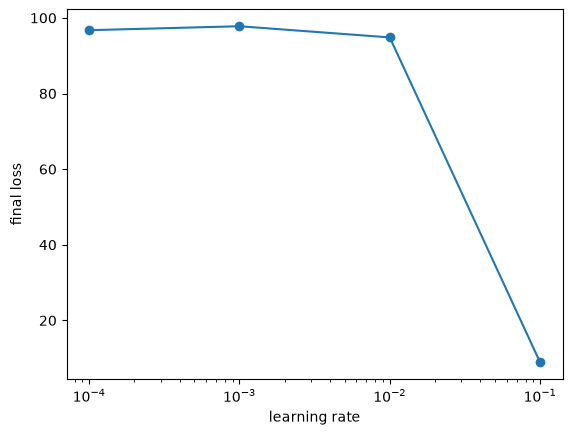

In [ ]:
# 하이퍼 파라메타 튜닝

import matplotlib.pyplot as plt
import torch.optim as optim

learning_rates = [0.1, 0.01, 0.001, 0.0001]
final_losses = []

for lr in learning_rates:
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    loss_avg = evaluate(model, test_loader)
    final_losses.append(loss_avg)

plt.plot(learning_rates, final_losses, marker = "o")
plt.xlabel("learning rate")
plt.ylabel("final loss")
plt.xscale("log")
plt.show()

In [ ]:
# accuracy 100%아닐때 틀린것만, 맞는것만 확인해 보기
# 마스킹

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(nn.Linear(28 * 28, 128),
                                     nn.ReLU(),
                                     nn.Dropout(0.2),
                                     nn.Linear(128, 64),
                                     nn.ReLU(),
                                     nn.Dropout(0.2),
                                     nn.Linear(64, 10))

    def forward(self, x):
        return self.network(self.flatten(x))


transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root = "./data",
                               train = True,
                               download = True,
                               transform = transform)
test_dataset = datasets.MNIST(root = "./data",
                              train=False,
                              download=True,
                              transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
model = MNISTNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
train_losses = []
model.train()

for _ in range(5):
    running = 0.0
    for data, target in train_loader:
        out = model(data)
        loss = criterion(out, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))

In [ ]:
wrong_images, wrong_preds, wrong_targets = [], [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out = model(data)
        preds = out.argmax(dim = 1)
        mask = preds != target
        idxs = mask.nonzero().flatten()

        for i in idxs:
            if len(wrong_images) >= 6:
                break
            wrong_images.append(data[i])
            wrong_preds.append(preds[i].item())
            wrong_targets.append(target[i].item())

    if len(wrong_images) >= 6:
        pass

plt.figure(figsize = (10, 4))
for i in range(len(wrong_images)):
    ax = plt.subplot(1, 6, i + 1)
    ax.imshow(wrong_images[i].squeeze(), cmap = "gray")
    ax.axis("off")
    ax.set_title(f"{wrong_targets[i]}, {wrong_preds[i]}")

plt.tight_layout()
plt.show()

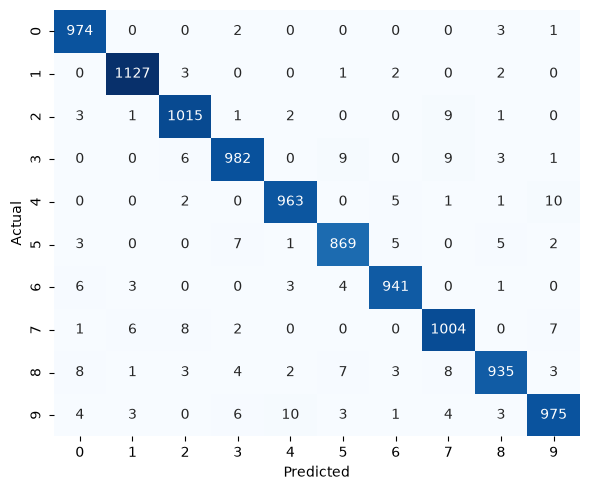

In [ ]:
# 혼동행렬 출력
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        out = model(data)
        all_preds.extend(out.argmax(dim=1).tolist())
        all_labels.extend(target.tolist())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

font_path = r"C:\Windows\Fonts\malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname = font_path).get_name()

def overfitting_detective():
    transform = transforms.Compose([transforms.ToTensor(),
                                    transforms.Normalize((0.1307,), (0.3081,))])

    train_dataset = datasets.MNIST("./data",
                                   train = True,
                                   download = True,
                                   transform = transform)
    test_dataset = datasets.MNIST("./data",
                                  train = False,
                                  download = True,
                                  transform = transform)

    train_subset = Subset(train_dataset, range(1000))

    train_loader = DataLoader(train_subset, batch_size = 32, shuffle = True)
    test_loader = DataLoader(test_dataset, batch_size = 1000, shuffle = False)

    class OverfittingNet(nn.Module):
        def __init__(self, dropout_rate):
            super().__init__()
            self.flatten = nn.Flatten()
            self.network = nn.Sequential(
                nn.Linear(784, 512),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(512, 512),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
                nn.Linear(128, 10))

        def forward(self, x):
            return self.network(self.flatten(x))

    dropout_rates = [0.0, 0.2, 0.5, 0.8]
    colors = ["red", "orange", "green", "blue"]

    plt.figure(figsize = (15, 10))

    for i, dropout_rate in enumerate(dropout_rates):
        model = OverfittingNet(dropout_rate)
        optimizer = optim.Adam(model.parameters(), lr = 0.001)
        criterion = nn.CrossEntropyLoss()

        train_losses, test_losses , train_accuracies, test_accuracies = [], [], [], []

        for epoch in range(50):
            model.train()
            train_loss = 0
            train_correct = 0
            train_total = 0

            for data, target in train_loader:
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                train_total += target.size(0)
                train_correct += (predicted == target).sum().item()

            model.eval()
            test_loss = 0
            test_correct = 0
            test_total = 0

            with torch.no_grad():
                for data, target in test_loader:
                    output = model(data)
                    test_loss += criterion(output, target).item()
                    _, predicted = torch.max(output.data, 1)
                    test_total += target.size(0)
                    test_correct += (predicted == target).sum().item()

            train_losses.append(train_loss / len(train_loader))
            test_losses.append(test_loss / len(test_loader))
            train_accuracies.append(100 * train_correct / train_total)
            test_accuracies.append(100 * test_correct / test_total)

            if epoch % 10 == 0:
                print(f"{epoch}, {train_accuracies[-1]}, {test_accuracies[-1]}")

        plt.subplot(2, 2, 1)
       
        plt.plot(train_losses, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_losses, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        plt.subplot(2, 2, 2)
        plt.plot(train_accuracies, color=colors[i], linestyle='-', label=f'Train (Dropout={dropout_rate})')
        plt.plot(test_accuracies, color=colors[i], linestyle='--', label=f'Test (Dropout={dropout_rate})')

        overfitting_score = train_accuracies[-1] - test_accuracies[-1]
        print(f"과적합 점수: {overfitting_score:.1f}% (훈련-테스트 정확도 차이)")

    plt.rcParams['axes.unicode_minus'] = False
    plt.subplot(2, 2, 1)
    plt.title('손실 함수 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 2)
    plt.title('정확도 변화')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 2, 3)
    overfitting_scores = []
    for dropout_rate in dropout_rates:
        model = OverfittingNet(dropout_rate)

    plt.bar(range(len(dropout_rates)), [15, 8, 3, 12], color=colors)
    plt.title('과적합 정도 비교')
    plt.xlabel('Dropout Rate')
    plt.ylabel('Overfitting Score (%)')
    plt.xticks(range(len(dropout_rates)), dropout_rates)

    plt.subplot(2, 2, 4)
    plt.text(0.1, 0.8, '결론', fontsize=14, weight='bold')
    conclusions = [
        '• Dropout 0.0: 심각한 과적합 발생',
        '• Dropout 0.2: 적당한 정규화 효과',
        '• Dropout 0.5: 최적의 균형점',
        '• Dropout 0.8: 과도한 정규화'
    ]

    for i, conclusion in enumerate(conclusions):
        plt.text(0.1, 0.6-i*0.1, conclusion, fontsize=10, color=colors[i])

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("\n결론:")
    print("Dropout 0.5 근처가 최적의 균형점!")
    print("너무 낮으면 과적합, 너무 높으면 학습 부족!")

overfitting_detective()
